# Data preperation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
NJCOM = pd.read_csv(r'C:/Users/ALIENWARE/Desktop/Personal Files/01_School Files/01_HOMEWORK Temporary keep/PS4DataFiles/ProblemSet4_NewJerseyOption.csv')

In [3]:
print(NJCOM.shape)
print('----------------------')
print(NJCOM.dtypes)
print('----------------------')
print(NJCOM.head(2))

(1476, 48)
----------------------
state                int64
county               int64
tract                int64
intptlat           float64
intptlon           float64
alandsqkm          float64
dist_to_rail       float64
dist_to_bigcity    float64
population15         int64
unitstot15           int64
natpctfor15        float64
povpctind15        float64
povpctfam15        float64
racpctwhi15        float64
tenpctown15        float64
tenpctren15        float64
unitpct2pl15       float64
occpctvac15        float64
compcttra15        float64
compctwlk15        float64
compctbic15        float64
compctdrv15        float64
medhhinc15           int64
medhhval15           int64
medgrossrent15       int64
medrooms15         float64
unemprate15        float64
labpartrate15      float64
population21         int64
unitstot21           int64
povpctind21        float64
natpctfor21        float64
povpctfam21        float64
racpctwhi21        float64
tenpctown21        float64
tenpctren21        fl

# 1. Calculate New Variables

## a. Variables normalized by density

In [4]:
# Population Density for both time periods (population / alandsqkm )
NJCOM['density_population15'] = NJCOM['population15']/NJCOM['alandsqkm']
NJCOM['density_population21'] = NJCOM['population21']/NJCOM['alandsqkm']

In [5]:
# Housing unit density for both time periods
NJCOM['density_unitstot15'] = NJCOM['unitstot15']/NJCOM['alandsqkm']
NJCOM['density_unitstot21'] = NJCOM['unitstot21']/NJCOM['alandsqkm']

In [6]:
# Column Check
NJCOM.head(2)

,state,county,tract,intptlat,intptlon,alandsqkm,dist_to_rail,dist_to_bigcity,population15,unitstot15,...,medhhinc21,medhhval21,medgrossrent21,medrooms21,unemprate21,labpartrate21,density_population15,density_population21,density_unitstot15,density_unitstot21
0,34,31,256804,41.078793,-74.377953,29.792621,44701.06527,151648.01740,6887,2506,...,124297,338600,1470,6.6,8.013029,64.401091,231.164623,186.690523,84.114788,78.475808
1,34,31,246300,40.910421,-74.264214,10.100083,0.00000,85997.74215,4677,1921,...,105625,369900,2159,4.8,7.158754,68.270448,463.065502,474.550556,190.196457,204.156738


## b. Variables change over time

In [7]:
# Population change 2015 to 2021
NJCOM['change_population'] = NJCOM['population21']-NJCOM['population15']

In [8]:
# Housing unit change 2015 to 2021
NJCOM['change_unit'] = NJCOM['unitstot21']-NJCOM['unitstot15']

In [9]:
# Median HH income change 2015 to 2021
NJCOM['change_medhhinc'] = NJCOM['medhhinc21']-NJCOM['medhhinc15']

In [10]:
# Median HH value change 2015 to 2021
NJCOM['change_medhhval'] = NJCOM['medhhval21']-NJCOM['medhhval15']

In [11]:
# Median gross rent change 2015 to 2021
NJCOM['change_medgrossrent'] = NJCOM['medgrossrent21']-NJCOM['medgrossrent15']

In [12]:
NJCOM.head(2)

,state,county,tract,intptlat,intptlon,alandsqkm,dist_to_rail,dist_to_bigcity,population15,unitstot15,...,labpartrate21,density_population15,density_population21,density_unitstot15,density_unitstot21,change_population,change_unit,change_medhhinc,change_medhhval,change_medgrossrent
0,34,31,256804,41.078793,-74.377953,29.792621,44701.06527,151648.01740,6887,2506,...,64.401091,231.164623,186.690523,84.114788,78.475808,-1325,-168,3903,-5200,-554
1,34,31,246300,40.910421,-74.264214,10.100083,0.00000,85997.74215,4677,1921,...,68.270448,463.065502,474.550556,190.196457,204.156738,116,141,33901,73400,586


## c. Recode binary categorical variables (0 or 1)

In [13]:
# shrank (population)
NJCOM['tracts_shrank_population'] = (NJCOM['population21']<NJCOM['population15']).astype(int)

In [14]:
# grew (population)
NJCOM['tracts_grew_population'] = (NJCOM['population21']>NJCOM['population15']).astype(int)

In [15]:
# added more than 100 housing units
NJCOM['added_100_units'] = ((NJCOM['unitstot21']-NJCOM['unitstot15'])>100).astype(int)

In [16]:
# lost more than 100 housing units 
NJCOM['lost_100_units'] = ((NJCOM['unitstot15']-NJCOM['unitstot21'])>100).astype(int)

In [17]:
NJCOM.head(2)

,state,county,tract,intptlat,intptlon,alandsqkm,dist_to_rail,dist_to_bigcity,population15,unitstot15,...,density_unitstot21,change_population,change_unit,change_medhhinc,change_medhhval,change_medgrossrent,tracts_shrank_population,tracts_grew_population,added_100_units,lost_100_units
0,34,31,256804,41.078793,-74.377953,29.792621,44701.06527,151648.01740,6887,2506,...,78.475808,-1325,-168,3903,-5200,-554,1,0,0,1
1,34,31,246300,40.910421,-74.264214,10.100083,0.00000,85997.74215,4677,1921,...,204.156738,116,141,33901,73400,586,0,1,1,0


In [18]:
NJCOM.to_csv("Updated_NewJerseyOption.csv", index=False)

## d. Create interaction Variables

In [19]:
# Ratio of median HH value to median HH income in each time period
NJCOM['ratio_hh_value_to_income_15'] = NJCOM['medhhval15']/NJCOM['medhhinc15']
NJCOM['ratio_hh_value_to_income_21'] = NJCOM['medhhval21']/NJCOM['medhhinc21']

In [20]:
# Ratio of median gross rent to median HH income in each time period
NJCOM['ratio_gross_value_to_income_15'] = NJCOM['medgrossrent15']/NJCOM['medhhinc15']
NJCOM['ratio_gross_value_to_income_21'] = NJCOM['medgrossrent21']/NJCOM['medhhinc21']

In [21]:
NJCOM.head(2)

,state,county,tract,intptlat,intptlon,alandsqkm,dist_to_rail,dist_to_bigcity,population15,unitstot15,...,change_medhhval,change_medgrossrent,tracts_shrank_population,tracts_grew_population,added_100_units,lost_100_units,ratio_hh_value_to_income_15,ratio_hh_value_to_income_21,ratio_gross_value_to_income_15,ratio_gross_value_to_income_21
0,34,31,256804,41.078793,-74.377953,29.792621,44701.06527,151648.01740,6887,2506,...,-5200,-554,1,0,0,1,2.855624,2.724120,0.016811,0.011827
1,34,31,246300,40.910421,-74.264214,10.100083,0.00000,85997.74215,4677,1921,...,73400,586,0,1,1,0,4.133902,3.502012,0.021931,0.020440


# 2. Train a classification model to predict future change for communities

In [22]:
from sklearn.model_selection import train_test_split

In [57]:
Array1 = NJCOM[['medhhinc15','unemprate15','dist_to_bigcity','unitstot15']].values
Array2 = NJCOM['tracts_shrank_population'].values

X_train, X_test, y_train, y_test = train_test_split(Array1, Array2, test_size=0.2, random_state=0)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("X_train shape:", X_train.dtype)
print("X_test shape:", X_test.dtype)
print("y_train:", y_train.dtype)
print("y_test:", y_test.dtype)

X_train shape: (1180, 4)
X_test shape: (296, 4)
y_train: (1180,)
y_test: (296,)
X_train shape: float64
X_test shape: float64
y_train: int32
y_test: int32


array([[<Axes: xlabel='medhhinc15', ylabel='medhhinc15'>,
        <Axes: xlabel='unemprate15', ylabel='medhhinc15'>,
        <Axes: xlabel='dist_to_bigcity', ylabel='medhhinc15'>,
        <Axes: xlabel='unitstot15', ylabel='medhhinc15'>],
       [<Axes: xlabel='medhhinc15', ylabel='unemprate15'>,
        <Axes: xlabel='unemprate15', ylabel='unemprate15'>,
        <Axes: xlabel='dist_to_bigcity', ylabel='unemprate15'>,
        <Axes: xlabel='unitstot15', ylabel='unemprate15'>],
       [<Axes: xlabel='medhhinc15', ylabel='dist_to_bigcity'>,
        <Axes: xlabel='unemprate15', ylabel='dist_to_bigcity'>,
        <Axes: xlabel='dist_to_bigcity', ylabel='dist_to_bigcity'>,
        <Axes: xlabel='unitstot15', ylabel='dist_to_bigcity'>],
       [<Axes: xlabel='medhhinc15', ylabel='unitstot15'>,
        <Axes: xlabel='unemprate15', ylabel='unitstot15'>,
        <Axes: xlabel='dist_to_bigcity', ylabel='unitstot15'>,
        <Axes: xlabel='unitstot15', ylabel='unitstot15'>]], dtype=object)

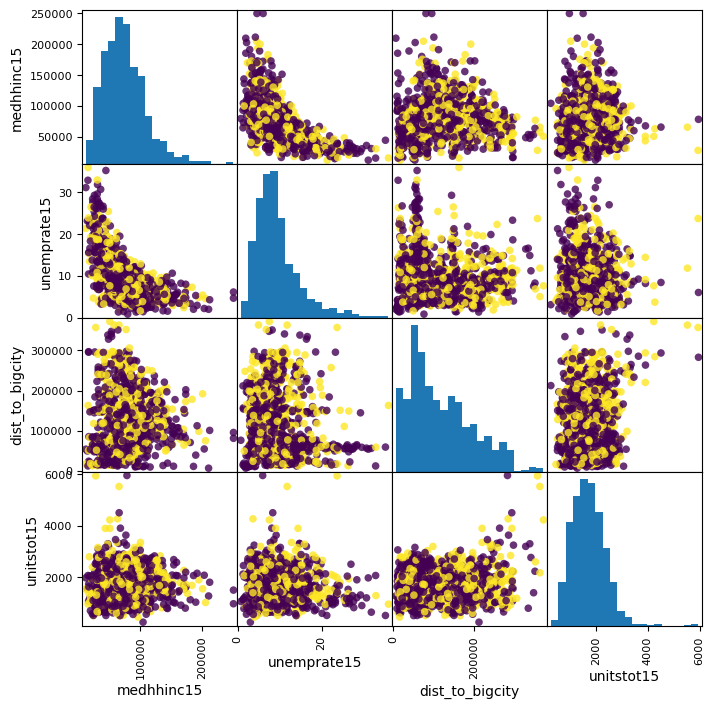

In [58]:
#data visualization
feature_names = ['medhhinc15','unemprate15','dist_to_bigcity','unitstot15']
train_NJCOM = pd.DataFrame(X_train, columns= feature_names)
pd.plotting.scatter_matrix(train_NJCOM, c=y_train, figsize=(8, 8),marker='o', hist_kwds={'bins': 20}, s=30, alpha=.8)

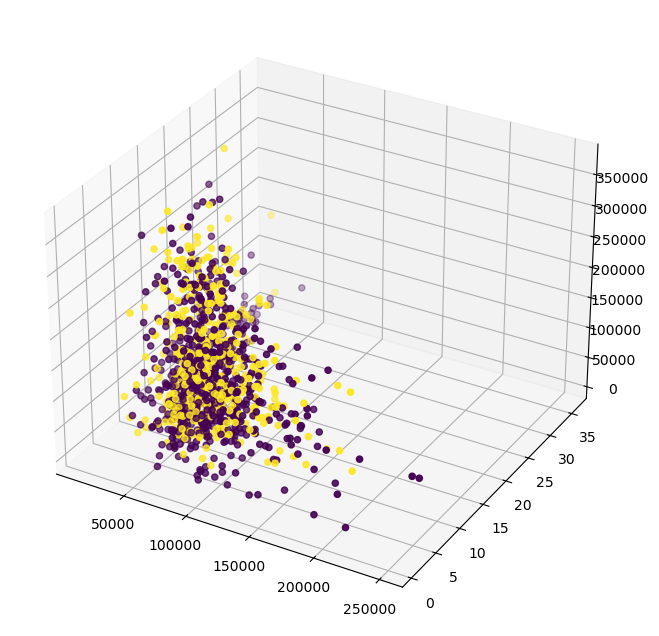

In [59]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
ax.scatter(train_NJCOM[feature_names].to_numpy()[:,0], 
           train_NJCOM[feature_names].to_numpy()[:,1], 
           train_NJCOM[feature_names].to_numpy()[:,2], c=y_train)
plt.show()

## K-Nearest Neighbor Classification to Predict Population Shrank

In [60]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# We can test a single prediction based on imagined data
prediction = knn.predict(X_train)
print("Prediction (Population Shrank):", prediction)

Prediction (Population Shrank): [1 1 0 ... 1 0 1]


In [61]:
y_pred = knn.predict(X_test)
print("Test set predictions:\n", y_pred)
print("Test set actual:\n", y_test)

# And based on that we can calculate the accuracy of our model as a score
print("Test set score: ", knn.score(X_test, y_test))

Test set predictions:
 [0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 0 0 0 0 1 0 1
 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 1 0 0 1
 0 1 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 1 1 1 0 1 0 0 1 1 0 0 1 0 0 1 1 0 0 1 1 1 1 1 0 0 0 0 0
 0 1 0 1 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0
 1 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0
 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 1 0 0 1 1 0 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0
 0 1 0 1 1 1 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 1 1 0 0 0 1 1 0 0 0 0 0]
Test set actual:
 [0 1 1 1 1 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 1 1 0 0 1 1 0 0 0 0 0 0 0
 1 0 1 0 1 1 0 1 1 0 1 1 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 1 1 1
 0 1 0 1 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 0 1 1 0 1 1 1 1 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 1 0
 1 0 0 0 0 0 1 1 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0

In [64]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.584
Confusion Matrix:
[[134  55]
 [ 68  39]]
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.71      0.69       189
           1       0.41      0.36      0.39       107

    accuracy                           0.58       296
   macro avg       0.54      0.54      0.54       296
weighted avg       0.57      0.58      0.58       296



## Logistic Regression Coefficients to gain insight into Population Shrank

In [66]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(C=1).fit(X_train, y_train)
y_pred_log_reg = logreg.predict(X_test)
# And then check the scores for training and test sets
print("Training set score: {:.3f}".format(logreg.score(X_train, y_train)))
print("Test set score: {:.3f}".format(logreg.score(X_test, y_test)))

Training set score: 0.605
Test set score: 0.655


In [67]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.3f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg))
print("Classification Report:")
print(classification_report(y_test, y_pred_log_reg))

Accuracy: 0.655
Confusion Matrix:
[[177  12]
 [ 90  17]]
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.94      0.78       189
           1       0.59      0.16      0.25       107

    accuracy                           0.66       296
   macro avg       0.62      0.55      0.51       296
weighted avg       0.64      0.66      0.59       296



## Random Forest Classifier

In [70]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(n_estimators=80, max_depth=12, max_features=5)
forest.fit(X_train, y_train)
y_pred_rf = forest.predict(X_test)
print(f"Training set score: {forest.score(X_train, y_train):.3f}")
print(f"Test set score: {forest.score(X_test, y_test):.3f}")

Training set score: 0.990
Test set score: 0.618


In [71]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.618
Confusion Matrix:
[[155  34]
 [ 79  28]]
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.82      0.73       189
           1       0.45      0.26      0.33       107

    accuracy                           0.62       296
   macro avg       0.56      0.54      0.53       296
weighted avg       0.59      0.62      0.59       296



## Mapping Test

In [34]:
NJ_gdf = gpd.read_file(r'C:/Users/ALIENWARE/Desktop/Personal Files/01_School Files/01_HOMEWORK Temporary keep/PS4DataFiles/tl_2023_34_tract/tl_2023_34_tract.shp')

In [35]:
NJCOM["state"] = NJCOM["state"].astype(str).str.zfill(2)    
NJCOM["county"] = NJCOM["county"].astype(str).str.zfill(3)  
NJCOM["tract"] = NJCOM["tract"].astype(str).str.zfill(6)   

# Create the GEOID by concatenating state, county, and tract
NJCOM["GEOID"] = NJCOM["state"] + NJCOM["county"] + NJCOM["tract"]

# Convert GEOID to string type in both datasets
NJCOM["GEOID"] = NJCOM["GEOID"].astype(str)
NJ_gdf["GEOID"] = NJ_gdf["GEOID"].astype(str)

In [36]:
print(NJCOM[["state", "county", "tract", "GEOID"]].head())

  state county   tract        GEOID
0    34    031  256804  34031256804
1    34    031  246300  34031246300
2    34    031  181200  34031181200
3    34    031  256803  34031256803
4    34    031  246003  34031246003


In [38]:
print("Shapefile Columns:", NJ_gdf.columns)
print("Dataset Columns:", NJCOM.columns)
NJCOM.head(2)

Shapefile Columns: Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'geometry', 'state', 'county', 'tract', 'intptlat',
       'intptlon', 'alandsqkm', 'dist_to_rail', 'dist_to_bigcity',
       'population15', 'unitstot15', 'natpctfor15', 'povpctind15',
       'povpctfam15', 'racpctwhi15', 'tenpctown15', 'tenpctren15',
       'unitpct2pl15', 'occpctvac15', 'compcttra15', 'compctwlk15',
       'compctbic15', 'compctdrv15', 'medhhinc15', 'medhhval15',
       'medgrossrent15', 'medrooms15', 'unemprate15', 'labpartrate15',
       'population21', 'unitstot21', 'povpctind21', 'natpctfor21',
       'povpctfam21', 'racpctwhi21', 'tenpctown21', 'tenpctren21',
       'unitpct2pl21', 'occpctvac21', 'compcttra21', 'compctwlk21',
       'compctbic21', 'compctdrv21', 'medhhinc21', 'medhhval21',
       'medgrossrent21', 'medrooms21', 'unemprate21', 'labpartrate21',
       'density_population1

,state,county,tract,intptlat,intptlon,alandsqkm,dist_to_rail,dist_to_bigcity,population15,unitstot15,...,change_medgrossrent,tracts_shrank_population,tracts_grew_population,added_100_units,lost_100_units,ratio_hh_value_to_income_15,ratio_hh_value_to_income_21,ratio_gross_value_to_income_15,ratio_gross_value_to_income_21,GEOID
0,34,031,256804,41.078793,-74.377953,29.792621,44701.06527,151648.01740,6887,2506,...,-554,1,0,0,1,2.855624,2.724120,0.016811,0.011827,34031256804
1,34,031,246300,40.910421,-74.264214,10.100083,0.00000,85997.74215,4677,1921,...,586,0,1,1,0,4.133902,3.502012,0.021931,0.020440,34031246300


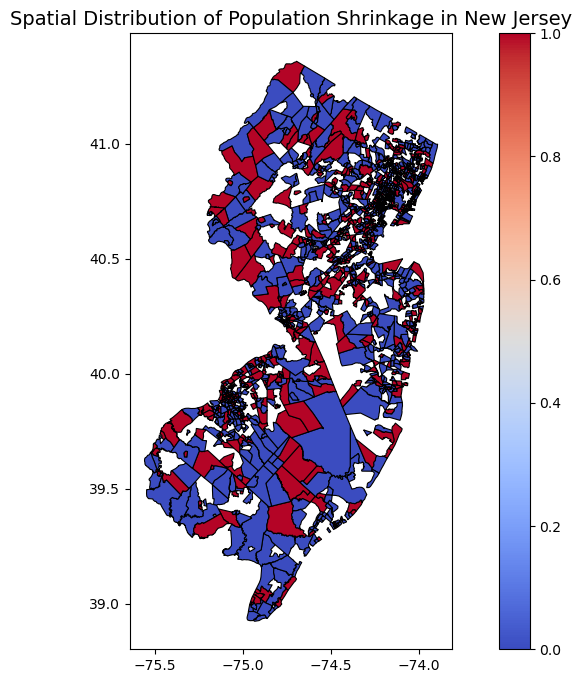

In [39]:
# Creat Interactive Map
NJ_gdf = NJ_gdf.merge(NJCOM, on='GEOID')

target_variable = NJCOM['tracts_shrank_population']

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
NJ_gdf.plot(column=target_variable, cmap='coolwarm', linewidth=0.8, edgecolor='black', legend=True, ax=ax)
ax.set_title(f"Spatial Distribution of Population Shrinkage in New Jersey", fontsize=14)
plt.show()

# 3. Train a regression model to predict future change for communities

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score

In [72]:
target_variable = ['change_population']
features = ['alandsqkm', 'dist_to_rail', 'dist_to_bigcity', 'population15', 'unitstot15', 'medhhinc15', 'medhhval15', 'medgrossrent15', 'unemprate15']

x_reg = NJCOM[features].values
y_reg = NJCOM[target_variable].values.ravel()

In [75]:
selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(x_reg, y_reg)
selected_features = [features[i] for i in selector.get_support(indices=True)]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_new, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

## K-Nearest Neighbors Regressor

In [44]:
from sklearn.neighbors import KNeighborsRegressor

In [77]:
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_knn_reg = knn_reg.predict(X_test_reg_scaled)

In [78]:
print("KNN Regression Results:")
print("R2 Score:", r2_score(y_test_reg, y_pred_knn_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_knn_reg)))

KNN Regression Results:
R2 Score: -0.015474234253463948
RMSE: 598.9412873359756


## OLS Regression Model

In [80]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [82]:
ols_reg = sm.OLS(y_train_reg, sm.add_constant(X_train_reg_scaled)).fit()
y_pred_ols_reg = ols_reg.predict(sm.add_constant(X_test_reg_scaled))

In [83]:
print("\nOLS Regression Results:")
print("R2 Score:", r2_score(y_test_reg, y_pred_ols_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_ols_reg)))
print("OLS Coefficients:")
print(pd.DataFrame({"Feature": ["Intercept"] + selected_features, "Coefficient": list(ols.params)}))


OLS Regression Results:
R2 Score: -0.0180823162061714
RMSE: 599.7099362109118
OLS Coefficients:
           Feature  Coefficient
0        Intercept   135.683898
1  dist_to_bigcity   -68.659544
2     population15   -82.142841
3       unitstot15    58.380059
4       medhhinc15    22.072210
5      unemprate15    24.160050


## Random Forest Regressor Model

In [50]:
from sklearn.ensemble import RandomForestRegressor

In [84]:
rf_reg = RandomForestRegressor(n_estimators=80, max_depth=12, max_features=5, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_reg)

In [85]:
print("\nRandom Forest Regression Results:")
print("R2 Score:", r2_score(y_test_reg, y_pred_rf_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)))
print("Feature Importance:")
print(pd.DataFrame({"Feature": selected_features, "Importance": rf.feature_importances_}).sort_values(by="Importance", ascending=False))


Random Forest Regression Results:
R2 Score: 0.013553788038014991
RMSE: 590.3186473286489
Feature Importance:
           Feature  Importance
0  dist_to_bigcity    0.229623
1     population15    0.215014
4      unemprate15    0.196989
3       medhhinc15    0.187644
2       unitstot15    0.170731


# 4. Writeup Analysis

## Description of the Data and Target Variables


The dataset used in this analysis contains information on the New Jersey census tract, focusing on key socioeconomic indicators such as population, housing units, median household income, and unemployment rate. The dataset records two time periods: 2015 and 2021, allowing for an analysis of changes over time.

The target variables for this study are:
Classification: Tracts that experienced population shrinkage, where data under column tracts_shrack_population being recoded into binary 0 or 1, 0 if shrinkage was true, 1 if shrinkage was not true.
Regression: Change in population from 2014 to 2021, where data under column change_population was assumed to be continuous data and is calculated.


## Classification Methods and Findings


The classification model is used to predict whether a given tract experiences population shrinkage, and results concluded by three different models are listed below:
K-Nearest Neighbors
Test Accuracy: ~59.3%
According to the confusion matrix, there’s a tendency for misclassification, which means the model might not capture enough distinction between shrinking and non-shrinking tracts.

Logistic Regression
Test Accuracy: ~65.5%
The logistic regression model performed better than K-Nearest Neighbors, and for features such as median household income and unemployment rate, it has a significant impact on predicting shrinkage.

Random Forest Classifier
Test Accuracy” ~64.2%
Even though the training accuracy was high at 98.8%, the test accuracy result can suggest potential overfitting. The most influential features are distance to big cities (27.5%), unemployment rate (25.3%), total housing units (25.2%), and median household income (22.0%).

Above all, while KNN was not a very good model to predict the tendency, Logistic Regression and Random Forest Classifier can still give us a brief insight into which features will influence the shrinking population. 


## Regression Methods and Findings


The regression models aimed to predict population change over time. Three methods were tested:
K-Nearest Neighbors Regressor
R² Score: -0.015
RMSE: ~598.94
The poor R² score indicates that KNN was not effective in capturing linear or non-linear relationships for this dataset.

Ordinary Least Squares Regression
R² Score: -0.018
RMSE: ~599.71
The negative R² suggests that the model performed worse than predicting the mean.
According to each coefficient:
Distance to big city (-68.66): Being closer to a city slightly increased population retention.
Unemployment rate (+24.16): Higher unemployment correlated with less population change.
Median household income (+22.07): Higher income was weakly correlated with growth.

Random Forest Regressor 
R² Score: 0.014
RMSE: ~590.32
While the R² is still low, Random Forest performed better than both KNN and OLS regression in prediction.
Similar to the classification model, distance to the big city, population size, unemployment rate, and household income were key predictors.

Above all, none of the regression models performed well, this may be because of the high variability in population changes that cannot be fully explained by the selected features.


## Additional Data and Alternate Approaches


To improve prediction additional data sources would be beneficial. For example, migration patterns from IRS migration data may show more insightful movement trends. Also access to public facilities such as education, healthcare, or transportation resources may also be influential to the changing population. If possible, more geographic data or related models could be used to facilitate the analysis. 


## Challenges and Reflections

Limited Predictive Power: Both classification and regression models struggled to achieve high accuracy or meaningful R² scores. This suggests that population changes are influenced by factors that are not included in the selected features.

Overfitting in Random Forest: The classifier achieved high training accuracy (~98%) but lower test accuracy (~64%), indicating a need for tuning parameters like max_depth or n_estimators.

For classification, the number of tracts that shrank vs. did not shrink was not perfectly balanced, which may have skewed results.

Overall, this study attempted to predict population shrinkage and population change using multiple machine-learning techniques. While classification models provided moderate predictive accuracy, regression models struggled to explain the variation in population change. Future research could integrate more granular data and alternative models to enhance predictive performance.
